In [1]:
import numpy as np

X_train = np.load("artifacts/X_train.npy")
X_test = np.load("artifacts/X_test.npy")
y_train = np.load("artifacts/y_train.npy")
y_test = np.load("artifacts/y_test.npy")
ft_train = np.load("artifacts/ft_train.npy", allow_pickle=True)
ft_test = np.load("artifacts/ft_test.npy", allow_pickle=True)

print("Train:", X_train.shape)

Train: (10585, 120)


In [13]:
# ==============================
# SVM FRUIT CLASSIFIER
# ==============================
from sklearn.svm import SVC
import joblib

svm_fruit = SVC(kernel='rbf')
svm_fruit.fit(X_train, ft_train)

joblib.dump(svm_fruit, "models/svm_fruit.pkl")

print("SVM fruit classifier trained")

SVM fruit classifier trained


In [14]:
# ==============================
# SVM EVALUATION (FRUIT TYPE)
# ==============================

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Predict on test set
y_pred = svm_fruit.predict(X_test)

# Accuracy
acc = accuracy_score(ft_test, y_pred)
print("Fruit Classification Accuracy:", acc)

# Classification report
print("\nClassification Report:")
print(classification_report(ft_test, y_pred))

# Confusion matrix
cm = confusion_matrix(ft_test, y_pred)

print("\nConfusion Matrix:\n", cm)

Fruit Classification Accuracy: 0.988666414809218

Classification Report:
              precision    recall  f1-score   support

       Apple       0.99      1.00      1.00       832
      Banana       0.99      1.00      0.99       975
    Capsicum       1.00      1.00      1.00       365
    Cucumber       1.00      0.89      0.94       190
      Potato       0.96      0.98      0.97       285

    accuracy                           0.99      2647
   macro avg       0.99      0.97      0.98      2647
weighted avg       0.99      0.99      0.99      2647


Confusion Matrix:
 [[830   1   0   0   1]
 [  0 975   0   0   0]
 [  0   0 365   0   0]
 [  1   8   0 169  12]
 [  5   2   0   0 278]]


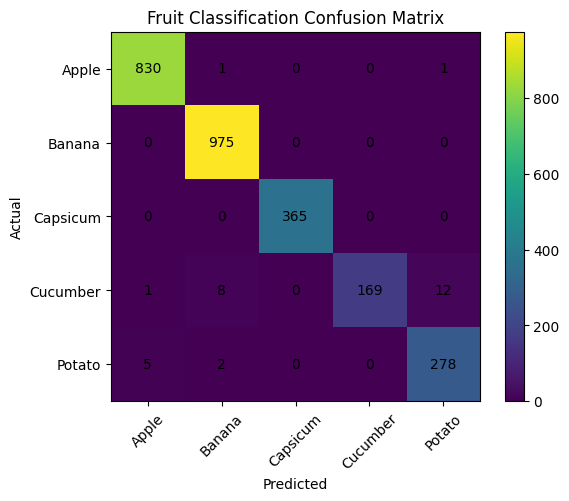

In [15]:
plt.figure()
plt.imshow(cm)
plt.title("Fruit Classification Confusion Matrix")
plt.colorbar()

classes = np.unique(ft_test)
plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("Actual")

# annotate values
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [2]:
import numpy as np
import joblib

mu_dict = {}
cov_dict = {}

for f in np.unique(ft_train):
    idx = (ft_train == f) & (y_train == 0)

    Xf = X_train[idx]

    # fallback if too few samples
    if len(Xf) < 5:
        continue

    mu_dict[f] = Xf.mean(axis=0)
    cov_dict[f] = np.cov(Xf, rowvar=False) + 1e-6*np.eye(Xf.shape[1])

# global fallback
global_fresh = X_train[y_train == 0]
g_mu = global_fresh.mean(axis=0)
g_cov = np.cov(global_fresh, rowvar=False) + 1e-6*np.eye(X_train.shape[1])

for f in np.unique(ft_train):
    if f not in mu_dict:
        mu_dict[f] = g_mu
        cov_dict[f] = g_cov

joblib.dump(mu_dict, "models/mu.pkl")
joblib.dump(cov_dict, "models/cov.pkl")

['models/cov.pkl']

In [3]:
import numpy.linalg as npl

def mahal_batch(X, ft):
    M = np.zeros(len(X))

    for f in np.unique(ft):
        idx = (ft == f)

        mu = mu_dict[f]
        inv = npl.inv(cov_dict[f])

        diff = X[idx] - mu
        M[idx] = np.sqrt(np.sum(diff @ inv * diff, axis=1))

    return M

M_train = mahal_batch(X_train, ft_train)
M_test = mahal_batch(X_test, ft_test)

In [4]:
from sklearn.neighbors import NearestNeighbors
import joblib

fresh = X_train[y_train == 0]

knn = NearestNeighbors(n_neighbors=5)
knn.fit(fresh)

K_train = knn.kneighbors(X_train)[0].mean(axis=1)
K_test = knn.kneighbors(X_test)[0].mean(axis=1)

joblib.dump(knn, "models/knn.pkl")

['models/knn.pkl']

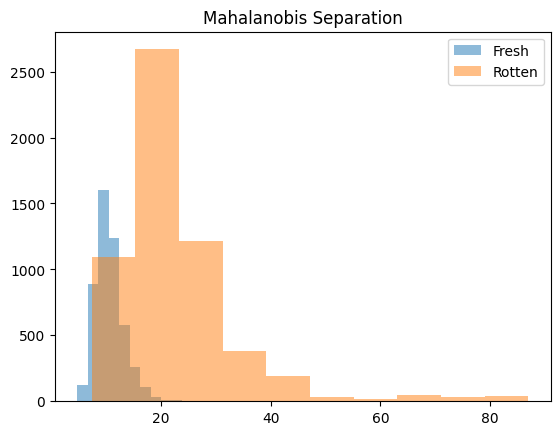

In [5]:
import matplotlib.pyplot as plt

plt.hist(M_train[y_train==0], alpha=0.5, label="Fresh")
plt.hist(M_train[y_train==1], alpha=0.5, label="Rotten")
plt.legend()
plt.title("Mahalanobis Separation")
plt.show()

In [7]:
### robust scalling 
from sklearn.preprocessing import RobustScaler
import joblib

robust = RobustScaler()

MK_train = np.vstack([M_train, K_train]).T
MK_test = np.vstack([M_test, K_test]).T

MK_train = robust.fit_transform(MK_train)
MK_test = robust.transform(MK_test)

joblib.dump(robust, "models/robust.pkl")

['models/robust.pkl']

In [ ]:
### logistic function --------->>>>>>   learn weights 
from sklearn.linear_model import LogisticRegression
import joblib

lr = LogisticRegression()
lr.fit(MK_train, y_train)

joblib.dump(lr, "models/lr.pkl")

['models/lr.pkl']

In [10]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = lr.predict(MK_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8571968265961466
              precision    recall  f1-score   support

           0       0.90      0.78      0.83      1215
           1       0.83      0.92      0.87      1432

    accuracy                           0.86      2647
   macro avg       0.86      0.85      0.85      2647
weighted avg       0.86      0.86      0.86      2647



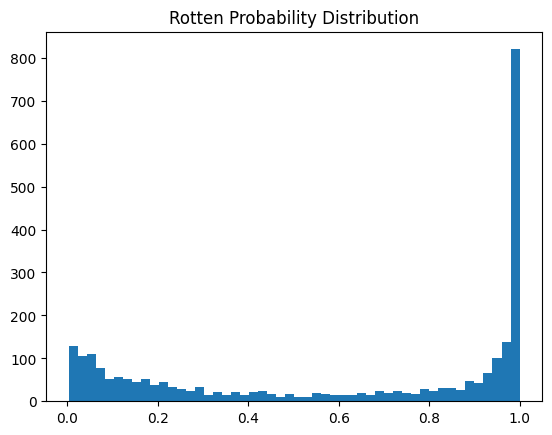

In [12]:
### probability plot 
p = lr.predict_proba(MK_test)[:,1]

import matplotlib.pyplot as plt

plt.hist(p, bins=50)
plt.title("Rotten Probability Distribution")
plt.show()

# nnnnnnnnnnnnnnnnnnnew

In [16]:
# ===== DASFS: Dual-Anchor Spectral Model =====
import joblib
import numpy as np

dasfs_dict = {}

for f in np.unique(ft_train):
    idx_fresh  = (ft_train == f) & (y_train == 0)
    idx_rotten = (ft_train == f) & (y_train == 1)

    if idx_fresh.sum() < 5 or idx_rotten.sum() < 5:
        continue

    mu_f = X_train[idx_fresh].mean(axis=0)
    mu_r = X_train[idx_rotten].mean(axis=0)

    # Degradation axis (unit vector)
    axis = mu_r - mu_f
    axis_norm = axis / (np.linalg.norm(axis) + 1e-8)

    # Project all training samples onto axis
    proj_fresh  = X_train[idx_fresh]  @ axis_norm
    proj_rotten = X_train[idx_rotten] @ axis_norm

    # Robust anchor points (use median, not mean)
    p_fresh  = np.median(proj_fresh)
    p_rotten = np.median(proj_rotten)

    # Spread for confidence estimation
    spread_fresh  = np.std(proj_fresh)
    spread_rotten = np.std(proj_rotten)

    dasfs_dict[f] = {
        "axis"          : axis_norm,
        "p_fresh"       : p_fresh,
        "p_rotten"      : p_rotten,
        "spread_fresh"  : spread_fresh,
        "spread_rotten" : spread_rotten
    }

joblib.dump(dasfs_dict, "models/dasfs.pkl")
print("DASFS anchors saved for fruits:", list(dasfs_dict.keys()))

DASFS anchors saved for fruits: ['Apple', 'Banana', 'Capsicum', 'Cucumber', 'Potato']


In [17]:
# ===== Evaluate DASFS on test set =====
def dasfs_score(x_vec, fruit, dasfs_dict):
    d = dasfs_dict[fruit]

    proj     = x_vec @ d["axis"]
    p_fresh  = d["p_fresh"]
    p_rotten = d["p_rotten"]
    spread   = (d["spread_fresh"] + d["spread_rotten"]) / 2

    # Normalized score 0→1 (1=fresh, 0=rotten)
    score = (p_rotten - proj) / (p_rotten - p_fresh + 1e-8)
    score = float(np.clip(score, 0, 1))

    # Confidence: how far from the decision boundary (midpoint)
    midpoint   = (p_fresh + p_rotten) / 2
    confidence = float(np.clip(abs(proj - midpoint) / (spread + 1e-8), 0, 1))

    return score, confidence

# Test on held-out set
scores = []
for i in range(len(X_test)):
    f = ft_test[i]
    if f not in dasfs_dict:
        continue
    s, c = dasfs_score(X_test[i], f, dasfs_dict)
    scores.append((s, c, y_test[i]))

scores = np.array(scores)
# Binary accuracy: score > 0.5 → fresh (y=0)
pred_binary = (scores[:,0] > 0.5).astype(int)
true_binary = (scores[:,2] == 0).astype(int)

from sklearn.metrics import accuracy_score, classification_report
print("DASFS Accuracy:", accuracy_score(true_binary, pred_binary))
print(classification_report(true_binary, pred_binary, 
      target_names=["Rotten","Fresh"]))

DASFS Accuracy: 0.9180204004533434
              precision    recall  f1-score   support

      Rotten       0.93      0.92      0.92      1432
       Fresh       0.91      0.91      0.91      1215

    accuracy                           0.92      2647
   macro avg       0.92      0.92      0.92      2647
weighted avg       0.92      0.92      0.92      2647

